# CIE 2025/26 RWTH, PROJECT B, GROUP 13
Junchao Yu, Marius Neuhalfen

# Setup

In [1]:
import os
import sys
import itertools
import functools

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import sklearn

from pathlib import Path

In [2]:
pd.set_option('display.max_columns', 100)

Load data

In [4]:
target_folder = "Data2"
current_folder = os.getcwd()

if Path(current_folder).name != target_folder:
    os.chdir(Path(current_folder) / Path(target_folder))
print(os.getcwd())


/home/marius-neuhalfen/Documents/Perso/RWTH/CIE/Project_B/Data2


Convert data

In [ ]:
VARIABLES = {
      0: "TotalDeformation.csv",
      1: "DirectionalDeformation_X_axis.csv",
      2: "DirectionalDeformation_Y_axis.csv",
      3: "DirectionalDeformation_Z_axis.csv",
      4: "EquivalentStress.csv",
      5: "ShearStress_XY.csv",
      6: "ShearStress_XZ.csv",
      7: "ShearStress_YZ.csv",
  }
LOADS = {
    0: "Bigger_train",
    1: "Smaller_train",
}
SEASONS = {
    0: "Summer",
    1: "Winter",
}
HEALTHS = {
    0: "Perfect_structure",
    1: "ip_frst_Arc_defect_all_tracks_111",
    2: "ip_1and3track_3_arc_78910",
    3: "ip_first_track_3arc_78910",
    4: "Ip_1track_1_arc_345",
    5: "ip_3track_1_arc_678",
    6: "ip_2_arc_all_tracks_222",
}
TRAIN_CONFIGS = {
    0: "One_train_1st_track",
    1: "One_train_middle_track",
    2: "Two_trains_extreme_track_different_direction",
    3: "Two_trains_extreme_track_same_direction",
}
VARIABLE_NAMES = [var[:-4] for var in VARIABLES.values()]
NODE_NUMBERS = None

def combination_to_string(combination):
    train_config, load, season, health, variable = combination
    return f"{TRAIN_CONFIGS[train_config]}__{LOADS[load]}__{SEASONS[season]}__{HEALTHS[health]}__{VARIABLES[variable][:-4]}"

# Construct list of scenarios (combinations of train configs, loads, seasons, healths, variables)
#   Each scenario is a tuple of (train_config, load, season, health, variable), each encoded
#   as the corresponding key in the dictionaries above
combinations = itertools.product(
        TRAIN_CONFIGS.keys(),
        LOADS.keys(),
        SEASONS.keys(),
        HEALTHS.keys(),
        VARIABLES.keys()
    )
combinations = list(combinations)

# Group by variables, i.e. each group has all variables for one scenario
combinations_grouped_by_variable = [
    combinations[i:i + len(VARIABLES)] for i in range(0, len(combinations), len(VARIABLES))
]
# Group further by healths, i.e. each group has all healths for one scenario (train config, load, season)
combinations_grouped_by_health = [
    combinations_grouped_by_variable[i:i + len(HEALTHS)] for i in range(0, len(combinations_grouped_by_variable), len(HEALTHS))
]



In [10]:
combinations_grouped_by_health[0]

[[(0, 0, 0, 0, 0),
  (0, 0, 0, 0, 1),
  (0, 0, 0, 0, 2),
  (0, 0, 0, 0, 3),
  (0, 0, 0, 0, 4),
  (0, 0, 0, 0, 5),
  (0, 0, 0, 0, 6),
  (0, 0, 0, 0, 7)],
 [(0, 0, 0, 1, 0),
  (0, 0, 0, 1, 1),
  (0, 0, 0, 1, 2),
  (0, 0, 0, 1, 3),
  (0, 0, 0, 1, 4),
  (0, 0, 0, 1, 5),
  (0, 0, 0, 1, 6),
  (0, 0, 0, 1, 7)],
 [(0, 0, 0, 2, 0),
  (0, 0, 0, 2, 1),
  (0, 0, 0, 2, 2),
  (0, 0, 0, 2, 3),
  (0, 0, 0, 2, 4),
  (0, 0, 0, 2, 5),
  (0, 0, 0, 2, 6),
  (0, 0, 0, 2, 7)],
 [(0, 0, 0, 3, 0),
  (0, 0, 0, 3, 1),
  (0, 0, 0, 3, 2),
  (0, 0, 0, 3, 3),
  (0, 0, 0, 3, 4),
  (0, 0, 0, 3, 5),
  (0, 0, 0, 3, 6),
  (0, 0, 0, 3, 7)],
 [(0, 0, 0, 4, 0),
  (0, 0, 0, 4, 1),
  (0, 0, 0, 4, 2),
  (0, 0, 0, 4, 3),
  (0, 0, 0, 4, 4),
  (0, 0, 0, 4, 5),
  (0, 0, 0, 4, 6),
  (0, 0, 0, 4, 7)],
 [(0, 0, 0, 5, 0),
  (0, 0, 0, 5, 1),
  (0, 0, 0, 5, 2),
  (0, 0, 0, 5, 3),
  (0, 0, 0, 5, 4),
  (0, 0, 0, 5, 5),
  (0, 0, 0, 5, 6),
  (0, 0, 0, 5, 7)],
 [(0, 0, 0, 6, 0),
  (0, 0, 0, 6, 1),
  (0, 0, 0, 6, 2),
  (0, 0, 0, 6, 3),
  (0, 

In [20]:
def read_data_file(
    train_config: int = 0,
    load: int = 0,
    season: int = 0,
    health: int = 0,
    variable: int = 0,
):
  """Reads data according to format and provides the data-frame as-is, with
  the categorical variables added as columns."""

  # Construct filename from scenario according to the folder structure

  results_paths = ["Results", "Results1"]

  for results_path in results_paths:
      filename = Path()
      filename /= TRAIN_CONFIGS[train_config]
      filename /= LOADS[load]
      filename /= SEASONS[season]
      filename /= HEALTHS[health]
      filename /= results_path  
      filename /= VARIABLES[variable]

      if filename.exists():
          break
  else:
      raise FileNotFoundError(f"Data file not found for combination: {combination_to_string((train_config, load, season, health, variable))}")
  
  # Encode the scenario as categorical columns 
  #   -> TODO: Is there a way of encoding that
  #   preserves information? E.g. like encoding the name of a city as its latitude
  df = pd.read_csv(filename)
  num_nodes = len(df)
  df["season"] = season*np.ones(num_nodes,dtype=np.uint8)
  df["health"] = health*np.ones(num_nodes,dtype=np.uint8)
  df["load"] = load*np.ones(num_nodes,dtype=np.uint8)
  df["train_config"] = train_config*np.ones(num_nodes,dtype=np.uint8)

  return df


def get_data():
  """
  Reads all data files from one health group and merges them 
  into a single data-frame.
  TODO: Make it read all scenarios, not just one.

  Returns:
      pd.DataFrame: Merged data-frame with all variables as columns.
  """
  global NODE_NUMBERS
  
  # Select one scenario that has same season, load and trains and goes through
  #   all healths and variables
  scenario = combinations_grouped_by_health[0] # TBD

  # Merge data for all healths in the scenario
  dfs_healths = []
  for same_health_combinations in scenario:
    dfs_variables = []

    #  Merge data for all variables in the current health scenario
    for same_variable_combination in same_health_combinations:
      print("Processing combination:", combination_to_string(same_variable_combination))

      var_name = VARIABLE_NAMES[same_variable_combination[-1]]

      # Get data file for current combination
      df = read_data_file(*same_variable_combination)

      # Turn the variable column into a single one and add a new time column
      df_melted = df.melt(id_vars=["Node Number","season","load","health","train_config"],var_name="variable",value_name=var_name)
      df_melted["time"] = df_melted["variable"].str[-3:].astype(np.float64)
      df_melted.drop(columns=["variable"],inplace=True)

      # Get node numbers and ensure they're consistent
      if NODE_NUMBERS is None:
        NODE_NUMBERS = df_melted["Node Number"].unique()
      else:
        try:
          assert all(NODE_NUMBERS == df_melted["Node Number"].unique())
        except ValueError or AssertionError:
          print("WARNING: Node numbers differ between data files!")
          print("Previous node numbers:", NODE_NUMBERS)
          print("Current node numbers:", df_melted["Node Number"].unique())

      dfs_variables.append(df_melted)

    # Concatenating all variables into a single data frame
    # -> we do an OUTER join, meaning all keys are kept (A U B)
    #   this should be safe, node numbers and the other shared columns are kept
    shared_cols = ["Node Number","season","load","health","train_config","time"]
    df_vars = functools.reduce(lambda left,right: pd.merge(left,right,on=shared_cols,
                                              how='outer'), dfs_variables)
    # Check that data has been preserved
    for df in dfs_variables:
      for var_name in VARIABLE_NAMES:
        if var_name in df.columns:
          merged = pd.merge(df[shared_cols + [var_name]], df_vars[shared_cols + [var_name]],
                            on=shared_cols, how='inner')
          assert len(merged) == len(df)

    dfs_healths.append(df_vars)

  # Check that columns are the same
  assert all(all(df.columns == dfs_healths[0].columns) for df in dfs_healths)

  # Concatenate them together
  df = pd.concat(dfs_healths,ignore_index=True)

  return df

df = get_data()

Processing combination: One_train_1st_track__Bigger_train__Summer__Perfect_structure__TotalDeformation
Processing combination: One_train_1st_track__Bigger_train__Summer__Perfect_structure__DirectionalDeformation_X_axis
Processing combination: One_train_1st_track__Bigger_train__Summer__Perfect_structure__DirectionalDeformation_Y_axis
Processing combination: One_train_1st_track__Bigger_train__Summer__Perfect_structure__DirectionalDeformation_Z_axis
Processing combination: One_train_1st_track__Bigger_train__Summer__Perfect_structure__EquivalentStress
Processing combination: One_train_1st_track__Bigger_train__Summer__Perfect_structure__ShearStress_XY
Processing combination: One_train_1st_track__Bigger_train__Summer__Perfect_structure__ShearStress_XZ
Processing combination: One_train_1st_track__Bigger_train__Summer__Perfect_structure__ShearStress_YZ
Processing combination: One_train_1st_track__Bigger_train__Summer__ip_frst_Arc_defect_all_tracks_111__TotalDeformation
Processing combination: 

In [21]:
df

,Node Number,season,load,health,train_config,TotalDeformation,time,DirectionalDeformation_X_axis,DirectionalDeformation_Y_axis,DirectionalDeformation_Z_axis,EquivalentStress,ShearStress_XY,ShearStress_XZ,ShearStress_YZ
0,1,0,0,0,0,0.000010,0.1,0.000003,0.000009,2.279800e-06,8727600.0,-392110.0,216100.0,517780.0
1,1,0,0,0,0,0.000011,0.5,0.000004,0.000009,4.379000e-06,14175000.0,-973950.0,420700.0,1028900.0
2,1,0,0,0,0,0.000010,0.9,0.000003,0.000009,2.283200e-06,8729500.0,-390000.0,216280.0,518170.0
3,1,0,0,0,0,0.000009,1.1,0.000004,0.000008,6.102300e-07,6162300.0,-2256900.0,-48168.0,13718.0
4,1,0,0,0,0,0.000010,1.5,0.000005,0.000008,1.077800e-06,10044000.0,-4697700.0,-115360.0,-3011.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1790665,25581,0,0,6,0,NaN,1.9,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1790666,25581,0,0,6,0,NaN,2.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1790667,25581,0,0,6,0,NaN,2.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1790668,25581,0,0,6,0,NaN,2.9,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Analyze node numbers

Go through all data files and check number of nodes. Create csv file that recaps these.

In [24]:
nums = []
for ix, combination in enumerate(combinations):
    num_nodes = len(read_data_file(*combination)["Node Number"].unique())
    entry = {}
    entry["train_config"] = combination[0]
    entry["load"] = combination[1]
    entry["season"] = combination[2]
    entry["health"] = combination[3]
    entry["variable"] = combination[4]
    entry["num_nodes"] = num_nodes
    nums.append(entry)
nums

[{'train_config': 0,
  'load': 0,
  'season': 0,
  'health': 0,
  'variable': 0,
  'num_nodes': 25581},
 {'train_config': 0,
  'load': 0,
  'season': 0,
  'health': 0,
  'variable': 1,
  'num_nodes': 25581},
 {'train_config': 0,
  'load': 0,
  'season': 0,
  'health': 0,
  'variable': 2,
  'num_nodes': 25581},
 {'train_config': 0,
  'load': 0,
  'season': 0,
  'health': 0,
  'variable': 3,
  'num_nodes': 25581},
 {'train_config': 0,
  'load': 0,
  'season': 0,
  'health': 0,
  'variable': 4,
  'num_nodes': 25581},
 {'train_config': 0,
  'load': 0,
  'season': 0,
  'health': 0,
  'variable': 5,
  'num_nodes': 25581},
 {'train_config': 0,
  'load': 0,
  'season': 0,
  'health': 0,
  'variable': 6,
  'num_nodes': 25581},
 {'train_config': 0,
  'load': 0,
  'season': 0,
  'health': 0,
  'variable': 7,
  'num_nodes': 25581},
 {'train_config': 0,
  'load': 0,
  'season': 0,
  'health': 1,
  'variable': 0,
  'num_nodes': 25581},
 {'train_config': 0,
  'load': 0,
  'season': 0,
  'health': 1,


Exemplary plot of node numbers throughout a number of scenarios.

<Axes: title={'center': 'Num. nodes per health state'}, xlabel='health'>

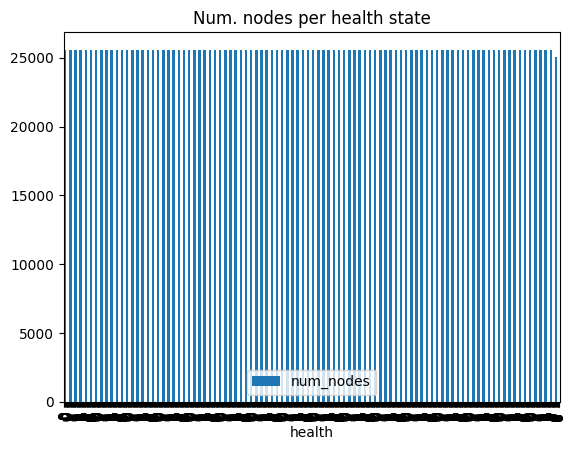

In [29]:
nn_df = pd.DataFrame(nums)
nn_df.plot(
    x="health", y="num_nodes", kind="bar",
    title=f"Num. nodes per health state"
)

In [31]:
# Save recap to file
# nn_df.to_csv("node_numbers_Data2_overview.csv", index=False)

# Visualize bridge

In [156]:
# Read tab seperated node export file
node_xyz = pd.read_csv(
    "/home/marius-neuhalfen/Documents/Perso/RWTH/CIE/Project_B/nodeExport.txt",
    sep="\t",
    engine="python"
)

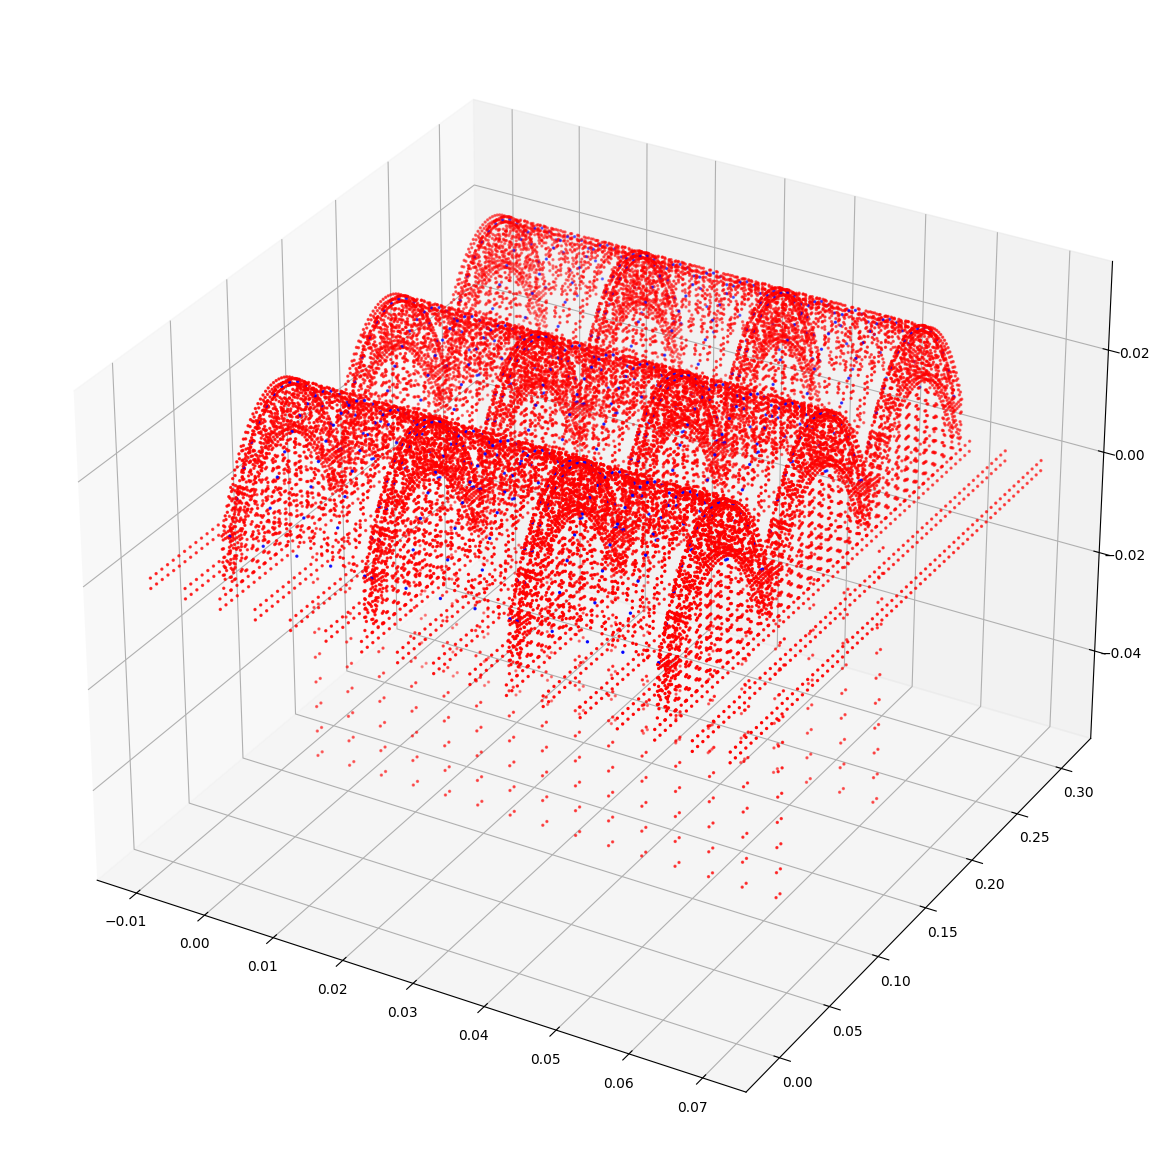

In [154]:
# Colors for missing nodes
missing_color = 'r'
colors = [
    missing_color if nn in missing_nn.values else 'b'
    for nn in node_xyz["Node Number"]
]

# 3D plot the bridge
fig = plt.figure(figsize=(15,15))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(
    node_xyz["X Location (m)"],
    node_xyz["Y Location (m)"],
    node_xyz["Z Location (m)"],
    c=colors, marker='o', s=2,
)
plt.show()

# Remove NaN

In [ ]:
df.dropna(inplace=True)
df

,Node Number,season,load,health,train_config,TotalDeformation,time,DirectionalDeformation_X_axis,DirectionalDeformation_Y_axis,DirectionalDeformation_Z_axis,EquivalentStress,ShearStress_XY,ShearStress_XZ,ShearStress_YZ
0,1,1,0,0,1,0.000023,0.1,-0.000007,-0.000021,4.003100e-06,7396700,499590.0,151830.0,312230.0
1,1,1,0,0,1,0.000023,0.5,-0.000007,-0.000020,8.941200e-06,6078200,1742900.0,349700.0,676220.0
2,1,1,0,0,1,0.000023,0.9,-0.000007,-0.000021,4.003300e-06,7397100,499580.0,151820.0,312080.0
3,1,1,0,0,1,0.000023,1.1,-0.000007,-0.000021,2.754700e-06,7469600,72965.0,119520.0,271660.0
4,1,1,0,0,1,0.000022,1.5,-0.000007,-0.000020,6.432000e-06,5667200,890290.0,286110.0,592400.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
154695,2210,1,0,6,1,0.000023,1.9,0.000009,0.000021,3.379000e-06,11523000,-79956.0,-54677.0,-83746.0
154696,2210,1,0,6,1,0.000023,2.1,0.000009,0.000020,4.467100e-06,10690000,499910.0,-129710.0,-76536.0
154697,2210,1,0,6,1,0.000023,2.5,0.000009,0.000019,9.954400e-06,9221500,1603200.0,-334820.0,-138610.0
154698,2210,1,0,6,1,0.000023,2.9,0.000009,0.000020,4.468600e-06,10691000,500170.0,-129700.0,-76228.0


# Plotting, Inspection

In [ ]:
df.dtypes

Node Number                        int64
season                             uint8
load                               uint8
health                             uint8
train_config                       uint8
TotalDeformation                 float64
time                             float64
DirectionalDeformation_X_axis    float64
DirectionalDeformation_Y_axis    float64
DirectionalDeformation_Z_axis    float64
EquivalentStress                   int64
ShearStress_XY                   float64
ShearStress_XZ                   float64
ShearStress_YZ                   float64
dtype: object

array([<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >], dtype=object)

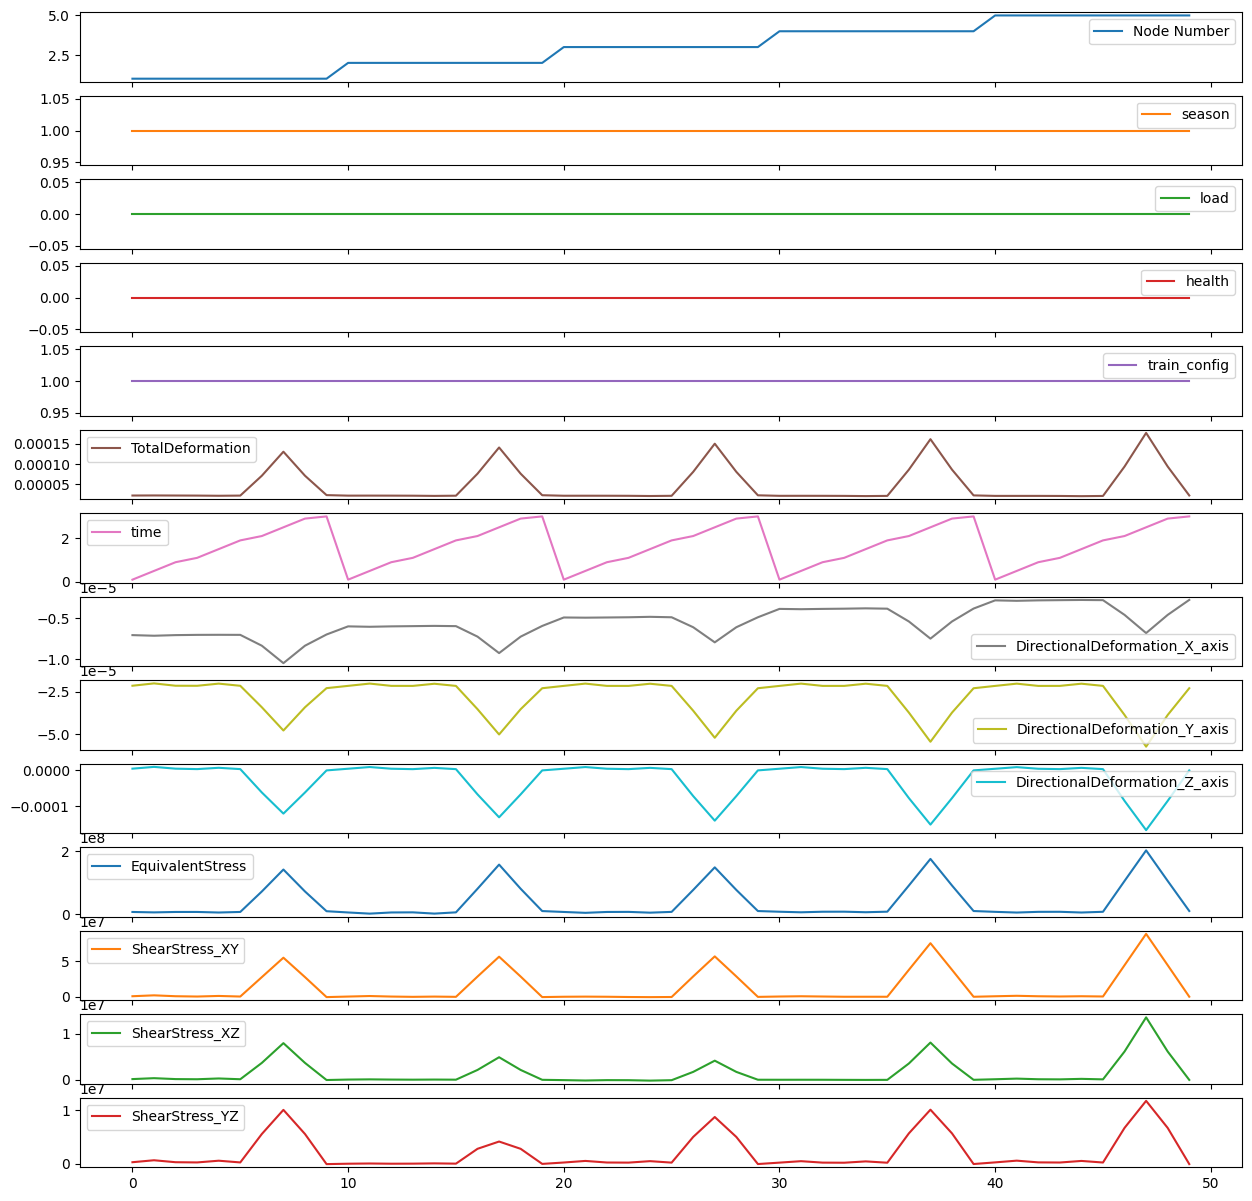

In [ ]:
m = 5
df.iloc[:m*10].plot(subplots=True,figsize=(15,15))

In [ ]:
df_sorted = df.sort_values(by=["Node Number","health","time"], ascending=[True, True, True])
# Attention - make sure the indices are reset after sorting
df_sorted.reset_index(drop=True, inplace=True)
df_sorted

,Node Number,season,load,health,train_config,TotalDeformation,time,DirectionalDeformation_X_axis,DirectionalDeformation_Y_axis,DirectionalDeformation_Z_axis,EquivalentStress,ShearStress_XY,ShearStress_XZ,ShearStress_YZ
0,1,1,0,0,1,0.000023,0.1,-0.000007,-0.000021,4.003100e-06,7396700,499590.0,151830.0,312230.0
1,1,1,0,0,1,0.000023,0.5,-0.000007,-0.000020,8.941200e-06,6078200,1742900.0,349700.0,676220.0
2,1,1,0,0,1,0.000023,0.9,-0.000007,-0.000021,4.003300e-06,7397100,499580.0,151820.0,312080.0
3,1,1,0,0,1,0.000023,1.1,-0.000007,-0.000021,2.754700e-06,7469600,72965.0,119520.0,271660.0
4,1,1,0,0,1,0.000022,1.5,-0.000007,-0.000020,6.432000e-06,5667200,890290.0,286110.0,592400.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
154695,2210,1,0,6,1,0.000023,1.9,0.000009,0.000021,3.379000e-06,11523000,-79956.0,-54677.0,-83746.0
154696,2210,1,0,6,1,0.000023,2.1,0.000009,0.000020,4.467100e-06,10690000,499910.0,-129710.0,-76536.0
154697,2210,1,0,6,1,0.000023,2.5,0.000009,0.000019,9.954400e-06,9221500,1603200.0,-334820.0,-138610.0
154698,2210,1,0,6,1,0.000023,2.9,0.000009,0.000020,4.468600e-06,10691000,500170.0,-129700.0,-76228.0


array([<Axes: >, <Axes: >, <Axes: >, <Axes: >], dtype=object)

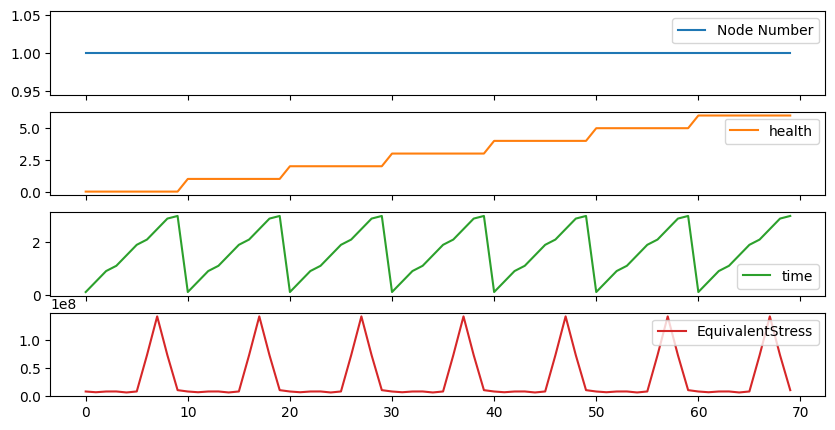

In [ ]:
df_sorted[["Node Number","health","time","EquivalentStress"]].iloc[:70].plot(subplots=True,figsize=(10,5))

Compare perfect and imperfect

In [ ]:
# Filter for health 0 and 1
df_comp = df_sorted[df_sorted["health"].isin([0, 1])]

df_pivot = df_comp.pivot_table(
    index=["Node Number","time","load","train_config","season"],
    columns="health",
    values=VARIABLE_NAMES
)
for variable in VARIABLE_NAMES:
    df_pivot[(variable, 'health_diff')] = df_pivot[(variable, 1)] - df_pivot[(variable, 0)]

df_diff = df_pivot[[ (var, 'health_diff') for var in VARIABLE_NAMES ]]
df_diff.columns = [var for var, _ in df_diff.columns]
df_diff.reset_index(inplace=True)
comp_diff_node_numbers = []
for var in VARIABLE_NAMES:
    for node_number in NODE_NUMBERS:
        if abs(df_diff[var][node_number]) > 0:
            comp_diff_node_numbers.append(node_number)
comp_diff_node_numbers = np.unique(comp_diff_node_numbers)
comp_diff_node_numbers

array([  17,   21,   77,   91,  147,  161,  177,  181,  191,  221,  227,
        257,  267,  287,  311,  319,  339,  371,  489,  549,  681,  807,
        847,  857,  897,  957,  969,  997, 1007, 1117, 1241, 1287, 1318,
       1561, 1647, 1687, 1697, 1747, 1877, 1887, 1899, 1929, 1967, 2027,
       2059, 2087, 2157])

Isolate nodes with changing variables

In [ ]:
df_time_mean = df_sorted.groupby(by=["Node Number","health"]).mean().reset_index()
df_time_std = df_sorted.groupby(by=["Node Number","health"]).std().reset_index()

In [ ]:

varying_nodes = []
for node_number in NODE_NUMBERS:
    not_same = False
    for var in VARIABLE_NAMES:
        unique_means = df_time_mean[df_time_mean["Node Number"]==node_number][var].unique()
        unique_stds = df_time_std[df_time_std["Node Number"]==node_number][var].unique()
        if len(unique_means) > 1 or len(unique_stds) > 1:
            not_same = True
    if not_same:
        varying_nodes.append(int(node_number))
len(varying_nodes), len(NODE_NUMBERS)

(588, 2210)

In [ ]:
# Only keep nodes with varying variables
df_varying = df_sorted[df_sorted["Node Number"].isin(varying_nodes)]
df_varying

,Node Number,season,load,health,train_config,TotalDeformation,time,DirectionalDeformation_X_axis,DirectionalDeformation_Y_axis,DirectionalDeformation_Z_axis,EquivalentStress,ShearStress_XY,ShearStress_XZ,ShearStress_YZ
70,2,1,0,0,1,0.000023,0.1,-0.000006,-0.000021,0.000004,5834100,36063.0,48821.0,32749.0
71,2,1,0,0,1,0.000023,0.5,-0.000006,-0.000020,0.000009,2148000,777020.0,93760.0,73674.0
72,2,1,0,0,1,0.000023,0.9,-0.000006,-0.000021,0.000004,5834800,36077.0,48797.0,32590.0
73,2,1,0,0,1,0.000022,1.1,-0.000006,-0.000021,0.000003,6189000,-363500.0,25728.0,45580.0
74,2,1,0,0,1,0.000022,1.5,-0.000006,-0.000020,0.000006,2232800,-18046.0,49417.0,96352.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
153785,2197,1,0,6,1,0.000021,1.9,0.000008,0.000009,0.000017,2479000,341300.0,29529.0,-36381.0
153786,2197,1,0,6,1,0.000026,2.1,0.000008,0.000009,0.000023,1963300,-453460.0,23353.0,-231050.0
153787,2197,1,0,6,1,0.000051,2.5,0.000008,0.000009,0.000050,4123000,-1449200.0,53271.0,-547450.0
153788,2197,1,0,6,1,0.000026,2.9,0.000008,0.000009,0.000023,1963800,-453600.0,23345.0,-231100.0


array([<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >], dtype=object)

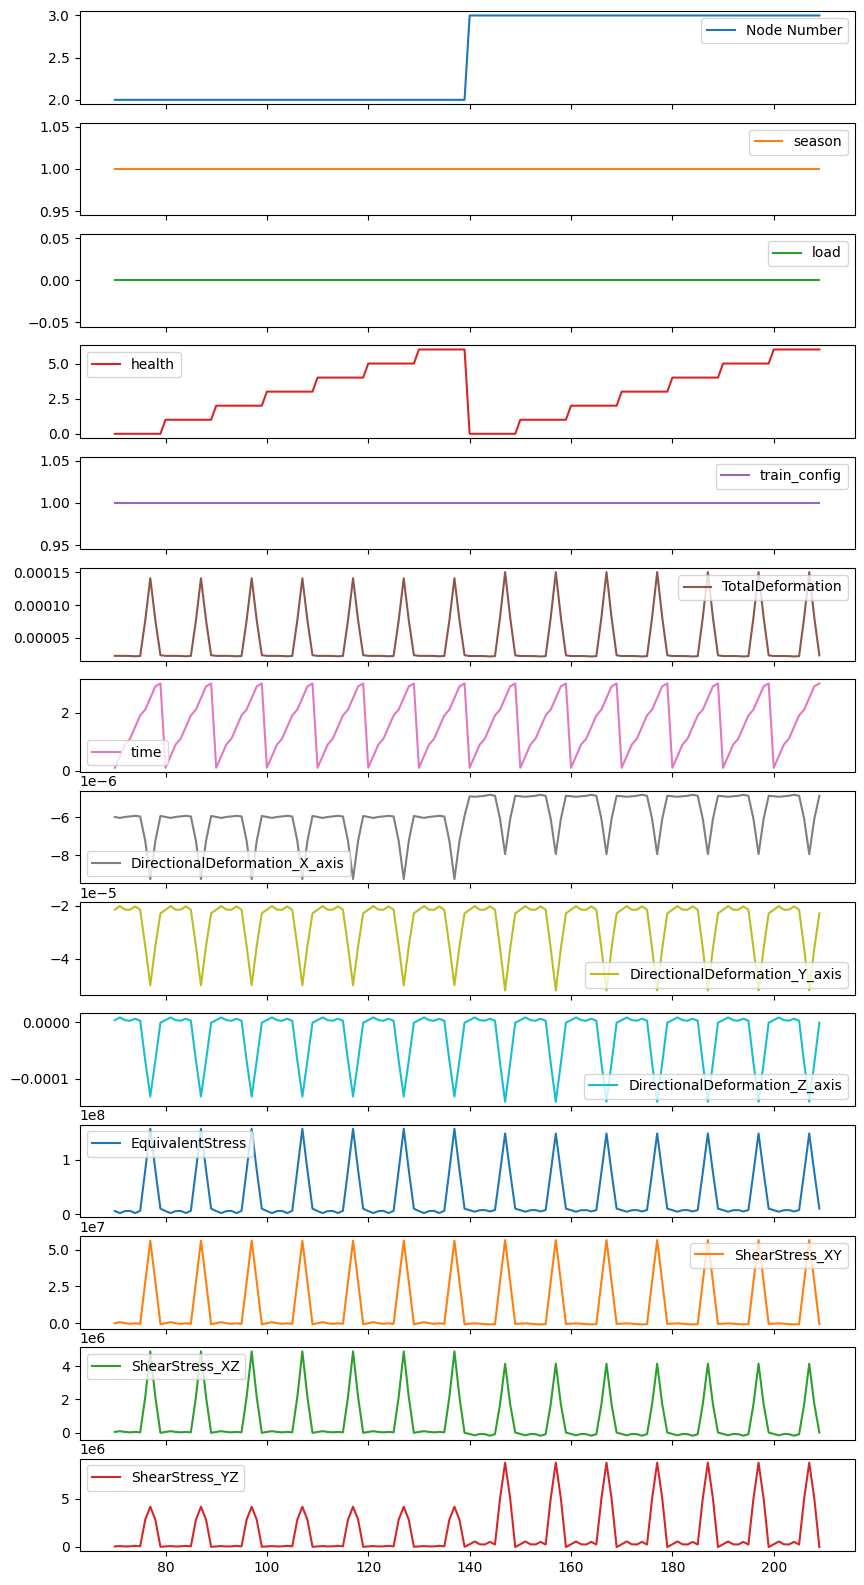

In [ ]:
df_varying.iloc[:140].plot(subplots=True,figsize=(10,20))

Get bridge structure

In [ ]:
len(NODE_NUMBERS)

2210

In [ ]:
from ipywidgets import interact, IntSlider

def integer_factors(n):
    """Returns the list of integer factors of n."""
    factors = []
    for i in range(1, n + 1):
        if n % i == 0:
            factors.append(i)
    return factors
def plot_integer_widths(node_numbers_of_interest: list[int]):
    """Plots the bridge structure as images for all possible widths."""
    img_widths = integer_factors(len(NODE_NUMBERS))
    for w in img_widths:
        img = np.zeros((w,len(NODE_NUMBERS)//w))
        flat_img = img.flatten()
        for i,node_number in enumerate(NODE_NUMBERS):
            if node_number in node_numbers_of_interest:
                flat_img[i] = 1
        img = flat_img.reshape(img.shape)
        plt.figure(figsize=(5,5))
        plt.imshow(img, cmap='gray', interpolation='nearest')
        plt.title(f'Node Variation Map (Width: {w})')
        plt.xlabel('Node Index')
        plt.ylabel('Node Index')
        plt.show()
def plot_load_by_widths_interactive(df, timestep):
    img_widths = integer_factors(len(NODE_NUMBERS))
    times = df["time"].unique()
    if timestep not in times:
        raise ValueError(f"Timestep {timestep} not found in data. Available times: {times}")
    df_time = df[df["time"] == timestep]
    def plot_at_width(width_idx):
        w = img_widths[width_idx]
        img = np.zeros((w, len(NODE_NUMBERS)//w))
        flat_img = img.flatten()
        for i, node_number in enumerate(NODE_NUMBERS):
            load_value = df_time[df_time["Node Number"] == node_number]["TotalDeformation"].values
            assert len(load_value) <= 1, f"Multiple load values found for node {node_number} at time {timestep}"
            if len(load_value) == 1:
                flat_img[i] = load_value[0]
        img = flat_img.reshape(img.shape)
        plt.figure(figsize=(5,5))
        plt.imshow(img, cmap='viridis', interpolation='nearest')
        plt.title(f'Bridge Load Map at time {timestep} (Width: {w}), (Height: {len(NODE_NUMBERS)//w})')
        plt.xlabel('Node Index')
        plt.ylabel('Node Index')
        plt.show()
    interact(plot_at_width, width_idx=IntSlider(min=0, max=len(img_widths)-1, step=1, value=0, description='Width Index'))

def plot_load_by_time_interactive(df, width):
    times = np.sort(df["time"].unique())
    def plot_at_time(time_idx):
        time = times[time_idx]
        df_time = df[df["time"] == time]
        img = np.zeros((width, len(NODE_NUMBERS)//width))
        flat_img = img.flatten()
        for i, node_number in enumerate(NODE_NUMBERS):
            load_value = df_time[df_time["Node Number"] == node_number]["TotalDeformation"].values
            assert len(load_value) <= 1, f"Multiple load values found for node {node_number} at time {time}"
            if len(load_value) == 1:
                flat_img[i] = load_value[0]
        img = flat_img.reshape(img.shape)
        plt.figure(figsize=(5,5))
        plt.imshow(img, cmap='viridis', interpolation='nearest')
        plt.title(f'Bridge Load Map at time {time} (Width: {width})')
        plt.xlabel('Node Index')
        plt.ylabel('Node Index')
        plt.show()
    interact(plot_at_time, time_idx=IntSlider(min=0, max=len(times)-1, step=1, value=0, description='Time Index'))


plot_load_by_widths_interactive(df_sorted[df_sorted["health"]==0], timestep=0.1)
plot_load_by_time_interactive(df_sorted[df_sorted["health"]==0], width=34)

interactive(children=(IntSlider(value=0, description='Width Index', max=15), Output()), _dom_classes=('widget-…

interactive(children=(IntSlider(value=0, description='Time Index', max=9), Output()), _dom_classes=('widget-in…

In [ ]:
2210/(42*3)

17.53968253968254

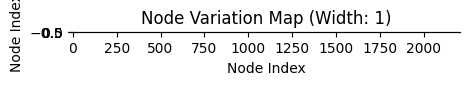

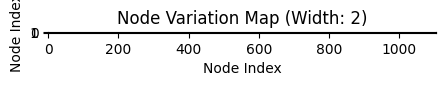

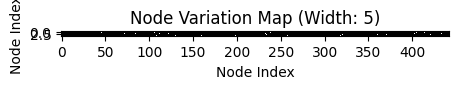

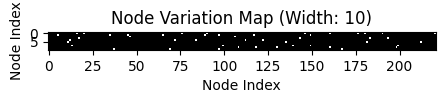

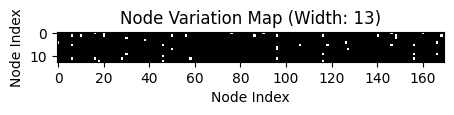

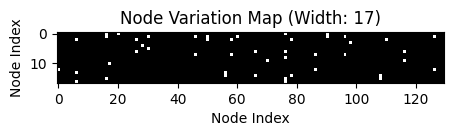

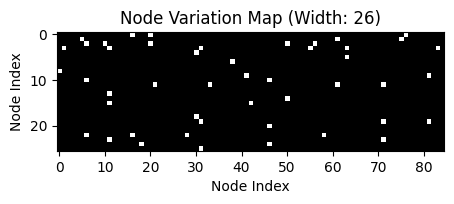

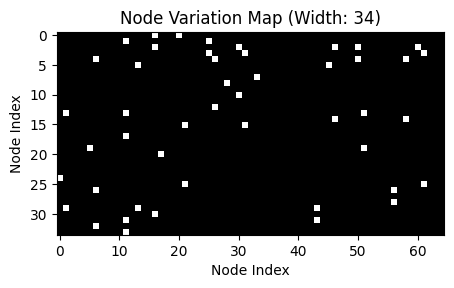

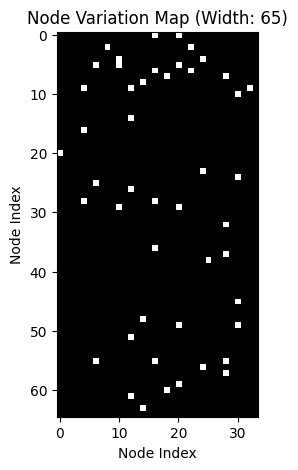

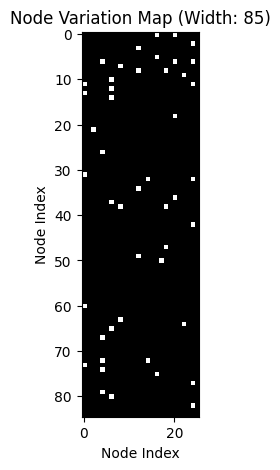

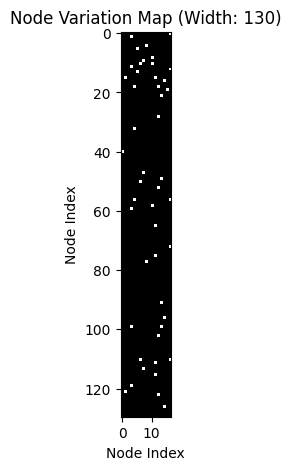

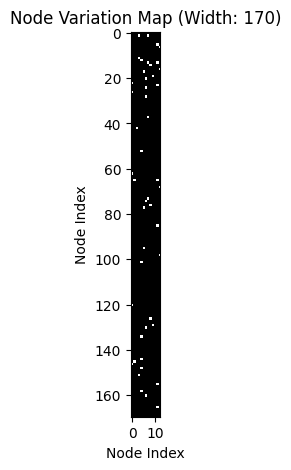

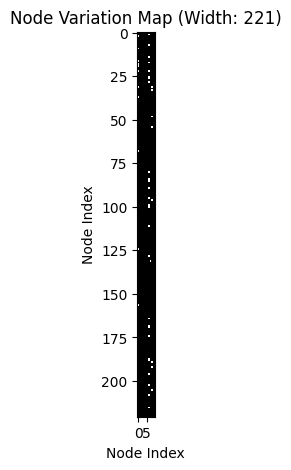

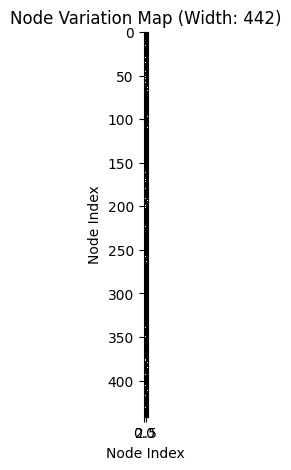

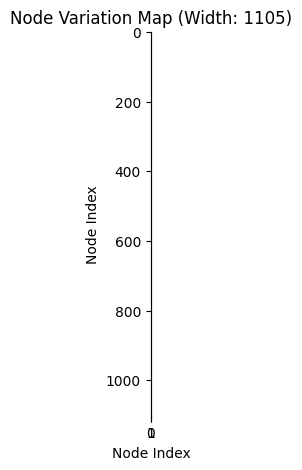

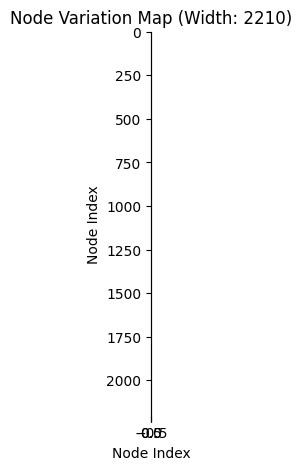

In [ ]:
plot_integer_widths(comp_diff_node_numbers)

# Training

In [ ]:
df_train = df_varying.copy()

In [ ]:
X_raw, y_raw = df_train.drop(columns=["health"]), df_train["health"]
X_train_raw, X_test_raw, y_train, y_test = sklearn.model_selection.train_test_split(
    X_raw, y_raw, test_size = 0.1, random_state = 0, shuffle=True,
)

In [ ]:
def standardize(X_train_raw, X_test_raw):
    scaler = sklearn.preprocessing.StandardScaler()

    scaler.fit(X_train_raw)
    X_train = scaler.transform(X_train_raw)
    X_test = scaler.transform(X_test_raw)

    return X_train, X_test

X_train, X_test = standardize(X_train_raw, X_test_raw)

Decision Tree

In [ ]:
# model = sklearn.tree.DecisionTreeClassifier()
# model.fit(X_train, y_train)

In [ ]:
# model.score(X_test, y_test), model.score(X_train, y_train)

Neural Network

In [ ]:
# model = sklearn.neural_network.MLPClassifier(hidden_layer_sizes=(1000,1000,1000),verbose=1)
# model.fit(X_train, y_train)

In [ ]:
# model.score(X_test, y_test), model.score(X_train, y_train)